===== DATA PREVIEW =====
   Gender  age      education  currentSmoker  cigsPerDay  BPMeds  \
0    Male   39   postgraduate              0         0.0     0.0   
1  Female   46  primaryschool              0         0.0     0.0   
2    Male   48     uneducated              1        20.0     0.0   
3  Female   61       graduate              1        30.0     0.0   
4  Female   46       graduate              1        23.0     0.0   

  prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0              no             0         0    195.0  106.0   70.0  26.97   
1              no             0         0    250.0  121.0   81.0  28.73   
2              no             0         0    245.0  127.5   80.0  25.34   
3              no             1         0    225.0  150.0   95.0  28.58   
4              no             0         0    285.0  130.0   84.0  23.10   

   heartRate  glucose Heart_ stroke  
0       80.0     77.0            No  
1       95.0     76.0            No  
2

C:\Users\Subhi Jain\AppData\Local\Temp\ipykernel_13532\2925434271.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Subhi Jain\AppData\Local\Temp\ipykernel_13532\2925434271.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

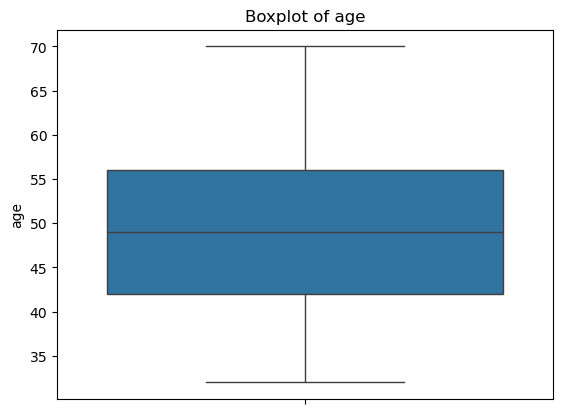

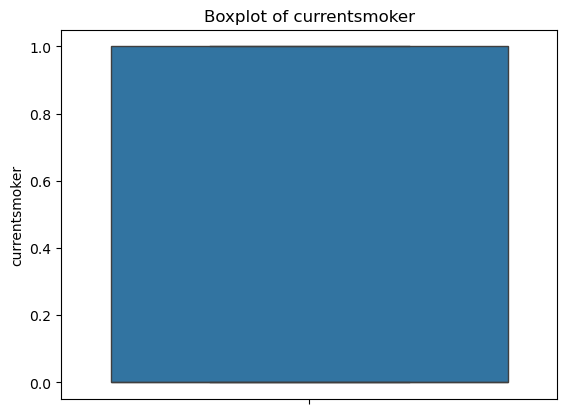

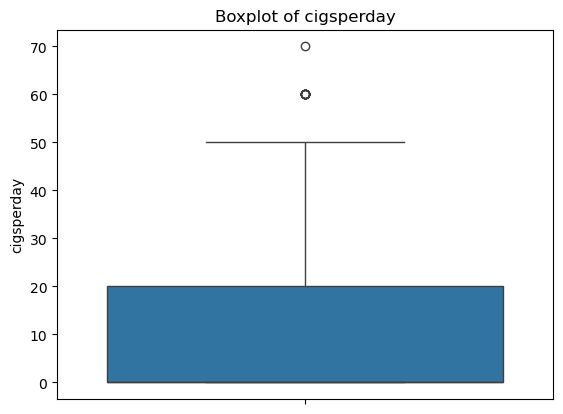

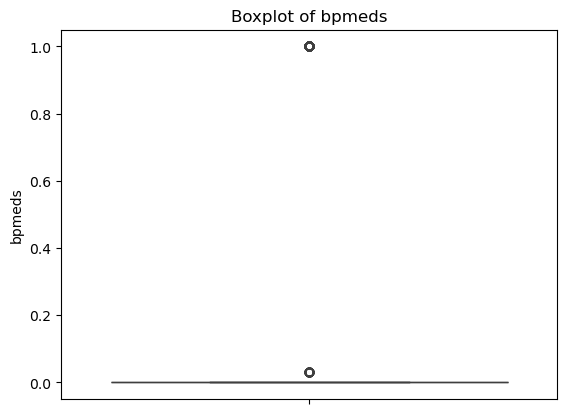

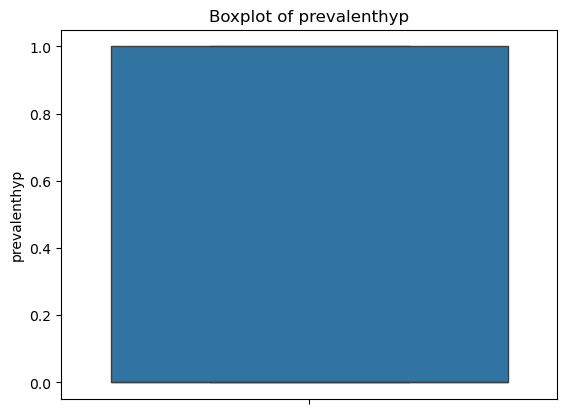

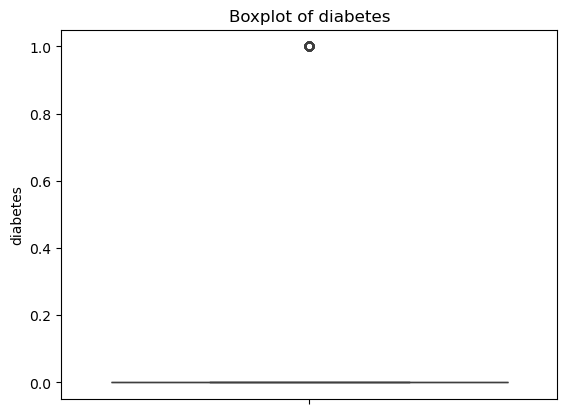

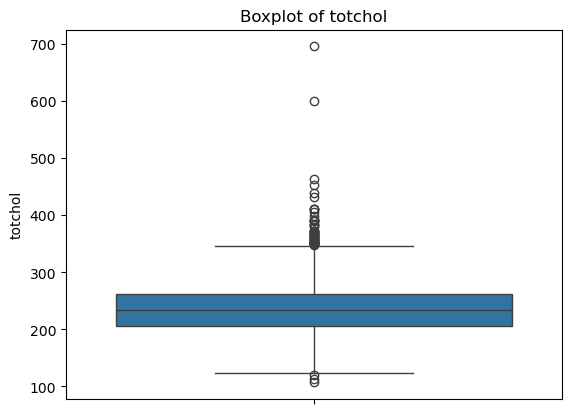

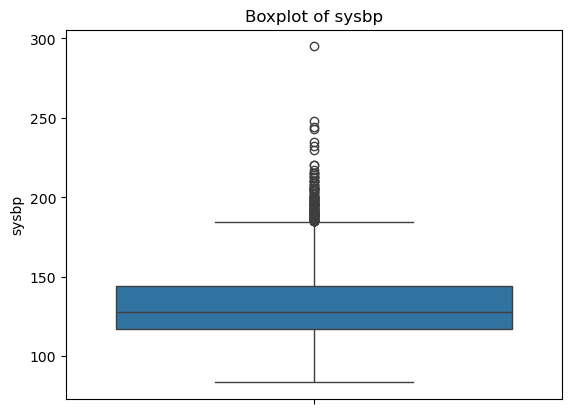

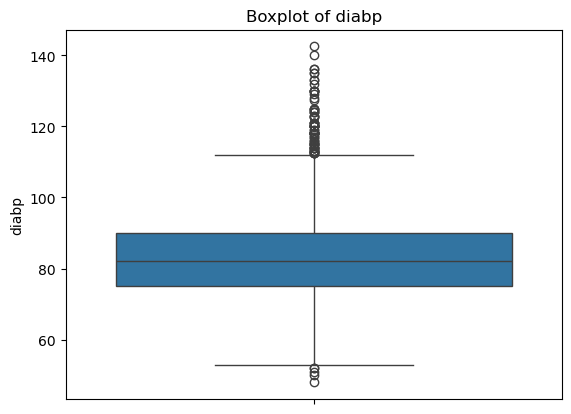

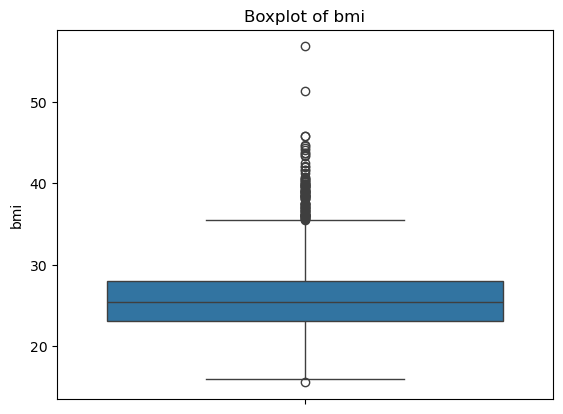

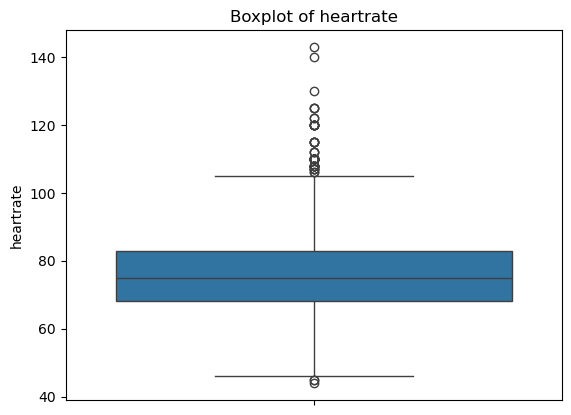

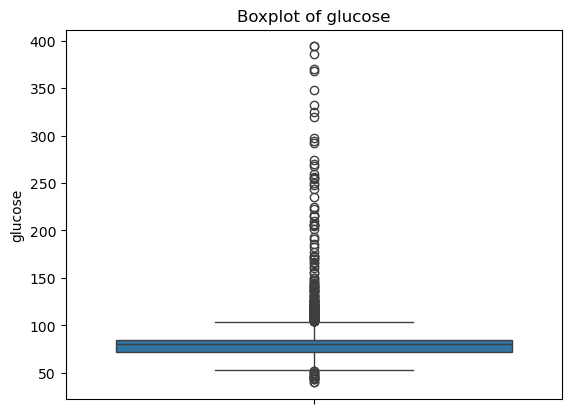


Outliers handled using IQR method.

Standardization Applied.
Log Transformation Applied where applicable.

===== FINAL DATASET =====
   gender       age      education  currentsmoker  cigsperday  bpmeds  \
0    male -1.234951   postgraduate      -0.988271   -0.763194     0.0   
1  female -0.418257  primaryschool      -0.988271   -0.763194     0.0   
2    male -0.184916     uneducated       1.011868    0.938008     0.0   
3  female  1.331800       graduate       1.011868    1.788609     0.0   
4  female -0.418257       graduate       1.011868    1.193188     0.0   

  prevalentstroke  prevalenthyp  diabetes   totchol     sysbp     diabp  \
0              no     -0.671101       0.0 -0.974747 -1.255196 -1.118089   
1              no     -0.671101       0.0  0.325744 -0.528621 -0.152197   
2              no     -0.671101       0.0  0.207518 -0.213772 -0.240006   
3              no      1.490089       0.0 -0.265388  0.876090  1.077119   
4              no     -0.671101       0.0  1.153330 

In [1]:
# ==========================================
# DATA WRANGLING - heart_disease dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# STEP 1: LOAD DATASET
# ------------------------------------------
df = pd.read_csv(r"C:\Users\Subhi Jain\Desktop\dsbda-prac_227\datasets\heart_disease.csv")

print("===== DATA PREVIEW =====")
print(df.head())

# ------------------------------------------
# STEP 2: CLEAN COLUMN NAMES
# ------------------------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nColumns:", df.columns)

# ------------------------------------------
# STEP 3: CHECK MISSING VALUES
# ------------------------------------------
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("\nAfter Handling Missing Values:")
print(df.isnull().sum())

# ------------------------------------------
# STEP 4: CHECK INCONSISTENCIES
# ------------------------------------------
print("\n===== DATA TYPES =====")
print(df.dtypes)

# Clean categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].unique())

# ------------------------------------------
# STEP 5: OUTLIER DETECTION
# ------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

print("\n===== OUTLIER DETECTION =====")

for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ------------------------------------------
# STEP 6: HANDLE OUTLIERS (IQR METHOD)
# ------------------------------------------
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return np.clip(column, lower, upper)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

print("\nOutliers handled using IQR method.")

# ------------------------------------------
# STEP 7: DATA TRANSFORMATION
# ------------------------------------------

# (A) Standardization (change scale)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nStandardization Applied.")

# (B) Log Transformation (reduce skewness)
for col in numeric_cols:
    if (df[col] > 0).all():
        df[col + "_log"] = np.log(df[col])

print("Log Transformation Applied where applicable.")

# ------------------------------------------
# FINAL DATASET
# ------------------------------------------
print("\n===== FINAL DATASET =====")
print(df.head())